In [1]:
import sys
import math
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from iapws import IAPWS97
import torch
import torch.nn as nn

sys.path.append("/mnt/data")
from eos_iapws_spline import EOSGridSpec, IAPWSDensitySpline

In [2]:
@dataclass(frozen=True)
class Forcing:
    time: np.ndarray
    tau: np.ndarray
    power: np.ndarray
    flow_in: np.ndarray
    flow_out: np.ndarray
    ntpc: np.ndarray
    mdot0: float

    @classmethod
    def from_excel(cls, path, t0_ramp=2.0):
        df = pd.read_excel(path)

        cols = ["Time [s]", "Flow-in [kg/s]", "Flow-out [kg/s]", "Power [W]", "NTPC"]
        df = df[cols].apply(pd.to_numeric, errors="coerce").dropna()
        df = df.sort_values("Time [s]")

        pre = df[
            (df["Time [s]"] >= 1.0)
            & (df["Time [s]"] <= 1.8)
            & (df["Power [W]"].abs() < 1e-12)
        ]

        mdot0 = float(pre["Flow-in [kg/s]"].mean())

        df = df[df["Time [s]"] >= t0_ramp].copy()
        time = df["Time [s]"].to_numpy()
        tau = time - t0_ramp

        return cls(
            time=time,
            tau=tau,
            power=df["Power [W]"].to_numpy(),
            flow_in=df["Flow-in [kg/s]"].to_numpy(),
            flow_out=df["Flow-out [kg/s]"].to_numpy(),
            ntpc=df["NTPC"].to_numpy(),
            mdot0=mdot0,
        )

    def power_torch(self, tau):
        x = tau.detach().cpu().numpy().reshape(-1)
        y = np.interp(x, self.tau, self.power)

        return torch.as_tensor(
            y,
            dtype=tau.dtype,
            device=tau.device,
        ).reshape_as(tau)

In [3]:
eos_path = Path("iapws_density_spline_25mpa.npz")

if eos_path.exists():
    eos = IAPWSDensitySpline.load(eos_path)
else:
    spec = EOSGridSpec(
        p_min=24.5e6,
        p_max=25.5e6,
        h_min=0.75e6,
        h_max=4.20e6,
        n_p=64,
        n_h=256,
        kx=3,
        ky=3,
        smoothing=0.0,
    )

    eos = IAPWSDensitySpline.build(spec)
    eos.save(eos_path)

In [4]:
@dataclass(frozen=True)
class MuGridSpec:
    p_ref: float = 25.0e6
    h_min: float = 0.75e6
    h_max: float = 4.20e6
    n_h: int = 512


class IAPWSViscositySpline:
    def __init__(self, spec, h_grid, mu_grid):
        self.spec = spec
        self.h_grid = np.asarray(h_grid, dtype=np.float64)
        self.mu_grid = np.asarray(mu_grid, dtype=np.float64)
        self.spline = CubicSpline(self.h_grid, self.mu_grid, bc_type="natural")

    @classmethod
    def build(cls, spec=MuGridSpec()):
        h_grid = np.linspace(spec.h_min, spec.h_max, spec.n_h)
        mu_grid = np.empty_like(h_grid)

        for i, h in enumerate(h_grid):
            mu_grid[i] = IAPWS97(P=spec.p_ref / 1e6, h=h / 1e3).mu

        return cls(spec, h_grid, mu_grid)

    def eval(self, h_abs, clip=True):
        h = np.asarray(h_abs, dtype=np.float64)

        if clip:
            h = np.clip(h, self.h_grid[0], self.h_grid[-1])

        return {
            "mu": self.spline(h),
            "mu_h": self.spline(h, 1),
        }

    def eval_torch(self, h_abs, clip=True):
        out = self.eval(
            h_abs.detach().cpu().numpy(),
            clip=clip,
        )

        mu_value = torch.as_tensor(
            out["mu"],
            device=h_abs.device,
            dtype=h_abs.dtype,
        )

        mu_h = torch.as_tensor(
            out["mu_h"],
            device=h_abs.device,
            dtype=h_abs.dtype,
        )

        mu = mu_value + mu_h * (h_abs - h_abs.detach())

        return {
            "mu": mu,
            "mu_h": mu_h,
        }


def smooth_abs(x, eps=1e-6):
    return torch.sqrt(x * x + eps * eps)


def darcy_lambda_torch(
    Re,
    roughness,
    Dh,
    model="swamee",
    Re_transition=2300.0,
    blend_width=200.0,
):
    Re = torch.clamp(Re, min=1.0)

    lam_laminar = 64.0 / Re

    if model == "blasius":
        lam_turb = 0.3164 / Re.pow(0.25)

    elif model == "swamee":
        rel = roughness / Dh
        arg = rel / 3.7 + 5.74 / Re.pow(0.9)
        lam_turb = 0.25 / torch.log10(arg).pow(2.0)

    else:
        raise ValueError("model must be 'blasius' or 'swamee'")

    s = torch.sigmoid((Re - Re_transition) / blend_width)

    return (1.0 - s) * lam_laminar + s * lam_turb

In [5]:
mu_spline = IAPWSViscositySpline.build(
    MuGridSpec(
        p_ref=25.0e6,
        h_min=0.75e6,
        h_max=4.20e6,
        n_h=512,
    )
)

In [6]:
@dataclass(frozen=True)
class Case:
    L: float
    Dh: float
    A: float

    p_ref: float
    p_out: float
    dp_ch: float
    p_in: float

    rho_pc: float
    h_pc: float
    Cp_pc: float
    beta_pc: float

    nspc: float
    h0_star: float

    kin: float
    kout: float
    Lambda: float
    roughness: float
    friction_model: str
    Re0: float
    lambda0: float
    Lambda_ref: float
    g: float

    mdot0: float
    G0: float
    rho0: float
    rho0_star: float
    w0: float

    G0_star: float
    dpi_star: float
    Fr: float

    roughness: float
    friction_model: str
    Re0: float
    lambda0: float
    Lambda_ref: float

    NQ_scale: float
    mass_scale: float
    mom_mid_scale: float
    mom_delta_scale: float
    energy_scale: float

    t_end_star: float
    t_kink_star: float

    @classmethod
    def build(cls, forcing, eos, nspc=2.0, alpha=0.02):
        L = 4.2672
        Dh = 8.36e-3
        A = math.pi * Dh**2 / 4

        p_ref = 25.0e6
        p_out = 25.0e6
        dp_ch = 0.12e6
        p_in = p_out + dp_ch

        rho_pc = 317.0348
        h_pc = 2152539.0
        Cp_pc = 76444.66
        beta_pc = 0.1285075

        h0_star = -nspc
        h0_abs = h_pc + (Cp_pc / beta_pc) * h0_star

        rho0 = float(np.asarray(eos.eval(p_ref, h0_abs)["rho"]))
        rho0_star = rho0 / rho_pc

        G0 = forcing.mdot0 / A
        w0 = G0 / rho0

        kin = 20.0
        kout = 20.0
        roughness = 2.5e-5
        friction_model = "swamee"   # можно заменить на "blasius"
        g = 9.81

        mu0 = IAPWS97(P=p_ref / 1e6, h=h0_abs / 1e3).mu
        Re0 = G0 * Dh / mu0

        if Re0 < 2300.0:
            lambda0 = 64.0 / Re0
        else:
            if friction_model == "blasius":
                lambda0 = 0.3164 / Re0**0.25
            elif friction_model == "swamee":
                lambda0 = 0.25 / (
                    np.log10(roughness / (3.7 * Dh) + 5.74 / Re0**0.9) ** 2
                )
            else:
                raise ValueError("friction_model must be 'blasius' or 'swamee'")

        Lambda_ref = lambda0 * L / (2.0 * Dh)

        # оставляем поле Lambda, чтобы старый код не ломался
        Lambda = Lambda_ref

        G0_star = G0 / (rho_pc * w0)
        dpi_star = dp_ch / (rho_pc * w0**2)
        Fr = w0**2 / (g * L)

        NQ = (
            beta_pc
            / Cp_pc
            * forcing.power
            / (rho_pc * w0 * A)
        )
        NQ_scale = max(float(np.max(np.abs(NQ))), 1.0)

        mass_scale = max(abs(G0_star), 1.0)
        energy_scale = NQ_scale
        mom_mid_scale = max(abs(dpi_star), 1.0)

        delta_max = (
            1.0 / math.sqrt(2.0 * math.pi)
            / (alpha * (0.5 * (1.0 + math.erf(1.0 / (alpha * math.sqrt(2.0)))) - 0.5))
        )

        local_coeff_max = Lambda + 0.5 * max(kin, kout) * delta_max
        local_loss_scale = local_coeff_max * G0_star**2 / rho0_star

        mom_delta_scale = max(abs(dpi_star), local_loss_scale, 1.0)

        t_end_star = float(forcing.tau[-1] * w0 / L)
        t_kink_star = float(10.0 * w0 / L)

        return cls(
            L=L,
            Dh=Dh,
            A=A,
            p_ref=p_ref,
            p_out=p_out,
            dp_ch=dp_ch,
            p_in=p_in,
            rho_pc=rho_pc,
            h_pc=h_pc,
            Cp_pc=Cp_pc,
            beta_pc=beta_pc,
            nspc=nspc,
            h0_star=h0_star,
            kin=kin,
            kout=kout,
            Lambda=Lambda,
            roughness=roughness,
            friction_model=friction_model,
            Re0=Re0,
            lambda0=lambda0,
            Lambda_ref=Lambda_ref,
            g=g,
            mdot0=forcing.mdot0,
            G0=G0,
            rho0=rho0,
            rho0_star=rho0_star,
            w0=w0,
            G0_star=G0_star,
            dpi_star=dpi_star,
            Fr=Fr,
            NQ_scale=NQ_scale,
            mass_scale=mass_scale,
            mom_mid_scale=mom_mid_scale,
            mom_delta_scale=mom_delta_scale,
            energy_scale=energy_scale,
            t_end_star=t_end_star,
            t_kink_star=t_kink_star,
        )

In [7]:
path = Path("Churkin-Kout20-Nspc2.0-Transient-Water-Vertical.xlsx")

forcing = Forcing.from_excel(path)
case = Case.build(forcing, eos, nspc=2.0, alpha=0.02)

print(f"mdot0           = {case.mdot0:.8f} kg/s")
print(f"rho0            = {case.rho0:.6f} kg/m3")
print(f"rho0*           = {case.rho0_star:.6f}")
print(f"w0              = {case.w0:.6f} m/s")
print(f"G0*             = {case.G0_star:.6f}")
print(f"Delta pi*       = {case.dpi_star:.6f}")
print(f"Fr              = {case.Fr:.6e}")
print(f"NQ scale        = {case.NQ_scale:.6f}")
print(f"mass scale      = {case.mass_scale:.6f}")
print(f"mom mid scale   = {case.mom_mid_scale:.6f}")
print(f"mom delta scale = {case.mom_delta_scale:.6f}")
print(f"energy scale    = {case.energy_scale:.6f}")
print(f"T_end*          = {case.t_end_star:.3f}")
print(f"Re0             = {case.Re0:.3f}")
print(f"lambda0         = {case.lambda0:.6f}")
print(f"Lambda_ref      = {case.Lambda_ref:.6f}")
print(f"friction model  = {case.friction_model}")

mdot0           = 0.09432138 kg/s
rho0            = 855.637767 kg/m3
rho0*           = 2.698876
w0              = 2.008250 m/s
G0*             = 2.698876
Delta pi*       = 93.850980
Fr              = 9.634374e-02
NQ scale        = 4.913639
mass scale      = 2.698876
mom mid scale   = 93.850980
mom delta scale = 1095.658303
energy scale    = 4.913639
T_end*          = 846.089
Re0             = 114090.521
lambda0         = 0.027530
Lambda_ref      = 7.026021
friction model  = swamee


In [8]:
class SmoothPINN(nn.Module):
    def __init__(self, t_end_star, width=128, depth=6, activation="tanh"):
        super().__init__()

        self.t_end_star = float(t_end_star)

        if activation == "tanh":
            act = nn.Tanh
        elif activation == "silu":
            act = nn.SiLU
        else:
            raise ValueError("activation must be 'tanh' or 'silu'")

        layers = []
        in_dim = 2

        for i in range(depth):
            layers.append(nn.Linear(in_dim if i == 0 else width, width))
            layers.append(act())

        self.net = nn.Sequential(*layers)
        self.head = nn.Linear(width, 3)

        self.reset_parameters()

    def reset_parameters(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, z, t):
        z_scaled = 2.0 * z - 1.0
        t_scaled = 2.0 * t / self.t_end_star - 1.0

        x = torch.cat([z_scaled, t_scaled], dim=1)
        y = self.head(self.net(x))

        G_hat = y[:, 0:1]
        h_hat = y[:, 1:2]
        Pi_hat = y[:, 2:3]

        return G_hat, h_hat, Pi_hat

In [9]:
class SineLayer(nn.Module):
    def __init__(self, in_dim, out_dim, omega0=1.0, first=False):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)
        self.omega0 = omega0
        self.first = first
        self.reset_parameters()

    def reset_parameters(self):
        in_dim = self.linear.in_features
        with torch.no_grad():
            if self.first:
                bound = 1.0 / in_dim
            else:
                bound = math.sqrt(6.0 / in_dim) / self.omega0
            self.linear.weight.uniform_(-bound, bound)
            self.linear.bias.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega0 * self.linear(x))


class SirenPINN(nn.Module):
    def __init__(self, width=64, depth=4, omega0_first=30.0, omega0_hidden=1.0):
        super().__init__()
        layers = [SineLayer(2, width, omega0=omega0_first, first=True)]
        for _ in range(depth - 1):
            layers.append(SineLayer(width, width, omega0=omega0_hidden))
        self.net = nn.Sequential(*layers)
        self.head = nn.Linear(width, 4)

    def forward(self, z_star, t_star):
        x = torch.cat([z_star, t_star], dim=1)
        y = self.head(self.net(x))

        rho = F.softplus(y[:, 0:1]) + 1e-8
        G = y[:, 1:2]
        h = y[:, 2:3]
        pi = y[:, 3:4]

        return rho, G, h, pi

In [10]:
class FourierFeatures(nn.Module):
    def __init__(self, freqs=(1.0, 2.0, 4.0, 8.0)):
        super().__init__()
        self.register_buffer(
            "freqs",
            torch.tensor(freqs, dtype=torch.float32).reshape(1, 1, -1),
        )

    def forward(self, x):
        # x: [N, 2], already scaled to [-1, 1]
        xb = x.unsqueeze(-1)                         # [N, 2, 1]
        arg = math.pi * xb * self.freqs              # [N, 2, F]

        sin = torch.sin(arg).flatten(start_dim=1)
        cos = torch.cos(arg).flatten(start_dim=1)

        return torch.cat([x, sin, cos], dim=1)


class HybridPINN(nn.Module):
    def __init__(
        self,
        t_end_star,
        width_smooth=128,
        width_fourier=64,
        depth_smooth=6,
        depth_fourier=3,
        freqs=(1.0, 2.0, 4.0, 8.0),
    ):
        super().__init__()

        self.t_end_star = float(t_end_star)
        self.fourier = FourierFeatures(freqs=freqs)

        smooth_layers = []
        in_dim = 2

        for i in range(depth_smooth):
            smooth_layers.append(nn.Linear(in_dim if i == 0 else width_smooth, width_smooth))
            smooth_layers.append(nn.Tanh())

        self.smooth_net = nn.Sequential(*smooth_layers)
        self.smooth_head = nn.Linear(width_smooth, 3)

        fourier_dim = 2 + 2 * 2 * len(freqs)

        fourier_layers = []
        for i in range(depth_fourier):
            fourier_layers.append(nn.Linear(fourier_dim if i == 0 else width_fourier, width_fourier))
            fourier_layers.append(nn.Tanh())

        self.fourier_net = nn.Sequential(*fourier_layers)
        self.fourier_head = nn.Linear(width_fourier, 3)

        self.gate_logit = nn.Parameter(torch.full((1, 3), -2.0))

        self.reset_parameters()

    def reset_parameters(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def scale_inputs(self, z, t):
        z_scaled = 2.0 * z - 1.0
        t_scaled = 2.0 * t / self.t_end_star - 1.0
        return torch.cat([z_scaled, t_scaled], dim=1)

    def forward(self, z, t):
        x = self.scale_inputs(z, t)

        y_smooth = self.smooth_head(self.smooth_net(x))

        x_fourier = self.fourier(x)
        y_fourier = self.fourier_head(self.fourier_net(x_fourier))

        gate = torch.sigmoid(self.gate_logit)

        y = y_smooth + gate * y_fourier

        G_hat = y[:, 0:1]
        h_hat = y[:, 1:2]
        Pi_hat = y[:, 2:3]

        return G_hat, h_hat, Pi_hat

In [11]:
def d(y, x):
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


def mse(x):
    return torch.mean(x**2)


def normal_pdf(x):
    return torch.exp(-0.5 * x**2) / math.sqrt(2.0 * math.pi)


def normal_cdf(x):
    return 0.5 * (1.0 + torch.erf(x / math.sqrt(2.0)))


def delta_inlet(z, alpha):
    a = torch.as_tensor(alpha, dtype=z.dtype, device=z.device)
    denom = a * (normal_cdf(1.0 / a) - normal_cdf(torch.zeros_like(a)))

    return normal_pdf(z / a) / denom


def delta_outlet(z, alpha):
    a = torch.as_tensor(alpha, dtype=z.dtype, device=z.device)
    denom = a * (normal_cdf(torch.zeros_like(a)) - normal_cdf(-1.0 / a))

    return normal_pdf((z - 1.0) / a) / denom

In [12]:
class Sampler:
    def __init__(self, case, device, dtype=torch.float32, alpha=0.02):
        self.case = case
        self.device = device
        self.dtype = dtype
        self.alpha = alpha

        self.t_bc = torch.linspace(
            0.0,
            case.t_end_star,
            4096,
            device=device,
            dtype=dtype,
        ).reshape(-1, 1)

        z_in = torch.linspace(0.0, 3.0 * alpha, 512, device=device, dtype=dtype).reshape(-1, 1)
        z_mid = torch.linspace(3.0 * alpha, 1.0 - 3.0 * alpha, 1024, device=device, dtype=dtype).reshape(-1, 1)
        z_out = torch.linspace(1.0 - 3.0 * alpha, 1.0, 512, device=device, dtype=dtype).reshape(-1, 1)

        self.z_ic = torch.cat([z_in, z_mid, z_out], dim=0)

    def uniform(self, n, a, b):
        return a + (b - a) * torch.rand(
            n,
            1,
            device=self.device,
            dtype=self.dtype,
        )

    def time(self, n):
        n0 = int(0.10 * n)
        nk = int(0.20 * n)
        nf = n - n0 - nk

        t_full = self.uniform(nf, 0.0, self.case.t_end_star)

        t_start = self.uniform(
            n0,
            0.0,
            min(0.05 * self.case.t_end_star, self.case.t_end_star),
        )

        dt = min(0.5 * self.case.w0 / self.case.L, 0.05 * self.case.t_end_star)
        a = max(0.0, self.case.t_kink_star - dt)
        b = min(self.case.t_end_star, self.case.t_kink_star + dt)

        t_kink = self.uniform(nk, a, b)

        return torch.cat([t_full, t_start, t_kink], dim=0)

    def interior(self, n_in=2048, n_mid=4096, n_out=2048):
        a = self.alpha

        z_in = self.uniform(n_in, 0.0, 3.0 * a)
        z_mid = self.uniform(n_mid, 3.0 * a, 1.0 - 3.0 * a)
        z_out = self.uniform(n_out, 1.0 - 3.0 * a, 1.0)

        return {
            "in": (z_in.requires_grad_(True), self.time(n_in).requires_grad_(True)),
            "mid": (z_mid.requires_grad_(True), self.time(n_mid).requires_grad_(True)),
            "out": (z_out.requires_grad_(True), self.time(n_out).requires_grad_(True)),
        }

    def bc(self):
        t = self.t_bc

        return {
            "in": (torch.zeros_like(t), t),
            "out": (torch.ones_like(t), t),
        }

    def ic(self):
        z = self.z_ic
        t = torch.zeros_like(z)

        return z, t

In [13]:
@dataclass(frozen=True)
class LossWeights:
    mass: float = 1.0
    mom: float = 1.0
    energy: float = 1.0
    ic: float = 20.0
    bc: float = 20.0

    mom_in: float = 1.0
    mom_mid: float = 1.0
    mom_out: float = 1.0


class Physics:
    def __init__(self, model, eos, mu_spline, case, forcing, alpha=0.02):
        self.model = model
        self.eos = eos
        self.mu_spline = mu_spline
        self.case = case
        self.forcing = forcing
        self.alpha = alpha

    def fields(self, z, t):
        G_hat, h_hat, Pi_hat = self.model(z, t)

        G = self.case.G0_star * G_hat
        h = self.case.nspc * h_hat
        pi = self.case.dpi_star * Pi_hat

        return G, h, pi, G_hat, h_hat, Pi_hat

    def eos25(self, h_star):
        h_abs = self.case.h_pc + (self.case.Cp_pc / self.case.beta_pc) * h_star
        p_abs = torch.full_like(h_abs, self.case.p_ref)

        raw = self.eos.eval_torch(p_abs, h_abs)

        rho_value = raw["rho"] / self.case.rho_pc

        chi_h = (
            self.case.Cp_pc
            / (self.case.beta_pc * self.case.rho_pc)
            * raw["rho_h"]
        )

        rho_star = rho_value + chi_h * (h_star - h_star.detach())

        return rho_star, chi_h

    def NQ_prime(self, t):
        tau = t * self.case.L / self.case.w0
        Q = self.forcing.power_torch(tau)

        return (
            self.case.beta_pc
            / self.case.Cp_pc
            * Q
            / (self.case.rho_pc * self.case.w0 * self.case.A)
        )
    
    def distributed_friction(self, G, h, rho):
        h_abs = self.case.h_pc + (self.case.Cp_pc / self.case.beta_pc) * h

        mu = self.mu_spline.eval_torch(h_abs)["mu"]

        G_abs_dim = self.case.rho_pc * self.case.w0 * smooth_abs(G, eps=1e-6)

        Re = G_abs_dim * self.case.Dh / mu

        lambda_darcy = darcy_lambda_torch(
            Re=Re,
            roughness=self.case.roughness,
            Dh=self.case.Dh,
            model=self.case.friction_model,
        )

        Lambda_dyn = lambda_darcy * self.case.L / (2.0 * self.case.Dh)

        signed_loss_flux = G * smooth_abs(G, eps=1e-6) / rho

        return Lambda_dyn, signed_loss_flux, Re, lambda_darcy

    def residuals_raw(self, z, t):
        G, h, pi, _, _, _ = self.fields(z, t)

        G_t = d(G, t)
        G_z = d(G, z)

        h_t = d(h, t)
        h_z = d(h, z)

        pi_z = d(pi, z)

        rho, chi_h = self.eos25(h)

        rho_t = chi_h * h_t
        rho_z = chi_h * h_z

        mom_flux = G**2 / rho

        mom_flux_z = (
            2.0 * G * G_z / rho
            - G**2 * rho_z / rho**2
        )

        Lambda_dyn, signed_loss_flux, Re, lambda_darcy = self.distributed_friction(
            G=G,
            h=h,
            rho=rho,
        )

        delta0 = delta_inlet(z, self.alpha)
        delta1 = delta_outlet(z, self.alpha)

        distributed_loss = Lambda_dyn * signed_loss_flux

        local_loss = (
            0.5 * self.case.kin * delta0 * signed_loss_flux
            + 0.5 * self.case.kout * delta1 * signed_loss_flux
        )

        R_mass = rho_t + G_z

        R_mom = (
            G_t
            + mom_flux_z
            + pi_z
            + rho / self.case.Fr
            + distributed_loss
            + local_loss
        )
        
        R_energy = (
            rho_t * h
            + rho * h_t
            + G_z * h
            + G * h_z
            - self.NQ_prime(t)
        )

        return R_mass, R_mom, R_energy

    def residuals_scaled(self, z, t, zone):
        R_mass, R_mom, R_energy = self.residuals_raw(z, t)

        R_mass = R_mass / self.case.mass_scale
        R_energy = R_energy / self.case.energy_scale

        if zone == "mid":
            R_mom = R_mom / self.case.mom_mid_scale
        else:
            R_mom = R_mom / self.case.mom_delta_scale

        return R_mass, R_mom, R_energy

    def pde_loss(self, points, weights):
        mass_loss = 0.0
        energy_loss = 0.0
        mom_losses = {}

        for zone in ["in", "mid", "out"]:
            z, t = points[zone]
            R_mass, R_mom, R_energy = self.residuals_scaled(z, t, zone)

            mass_loss = mass_loss + mse(R_mass)
            energy_loss = energy_loss + mse(R_energy)
            mom_losses[zone] = mse(R_mom)

        L_mass = mass_loss / 3.0
        L_energy = energy_loss / 3.0

        L_mom = (
            weights.mom_in * mom_losses["in"]
            + weights.mom_mid * mom_losses["mid"]
            + weights.mom_out * mom_losses["out"]
        )

        return {
            "mass": L_mass,
            "mom": L_mom,
            "energy": L_energy,
            "mom_in": mom_losses["in"],
            "mom_mid": mom_losses["mid"],
            "mom_out": mom_losses["out"],
        }

    def ic_loss(self, points):
        z, t = points
        G, h, _, _, _, _ = self.fields(z, t)

        R_G = G / self.case.G0_star - 1.0
        R_h = h / self.case.nspc + 1.0

        return {
            "ic_G": mse(R_G),
            "ic_h": mse(R_h),
        }

    def bc_loss(self, points):
        z_in, t_in = points["in"]
        z_out, t_out = points["out"]

        _, h_in, pi_in, _, _, _ = self.fields(z_in, t_in)
        _, _, pi_out, _, _, _ = self.fields(z_out, t_out)

        R_h_in = h_in / self.case.nspc + 1.0
        R_pi_in = pi_in / self.case.dpi_star - 1.0
        R_pi_out = pi_out / self.case.dpi_star

        return {
            "bc_h_in": mse(R_h_in),
            "bc_pi_in": mse(R_pi_in),
            "bc_pi_out": mse(R_pi_out),
        }

    def total_loss(self, sampler, weights):
        pde = self.pde_loss(sampler.interior(), weights)
        ic = self.ic_loss(sampler.ic())
        bc = self.bc_loss(sampler.bc())

        L_pde = (
            weights.mass * pde["mass"]
            + weights.mom * pde["mom"]
            + weights.energy * pde["energy"]
        )

        L_ic = ic["ic_G"] + ic["ic_h"]
        L_bc = bc["bc_h_in"] + bc["bc_pi_in"] + bc["bc_pi_out"]

        total = L_pde + weights.ic * L_ic + weights.bc * L_bc

        logs = {
            "loss": total,
            "pde": L_pde,
            "ic": L_ic,
            "bc": L_bc,
            **pde,
            **ic,
            **bc,
        }

        return total, logs

In [14]:
class Trainer:
    def __init__(self, model, physics, sampler, weights, lr=1e-4):
        self.model = model
        self.physics = physics
        self.sampler = sampler
        self.weights = weights
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    def step(self):
        self.optimizer.zero_grad(set_to_none=True)

        loss, logs = self.physics.total_loss(self.sampler, self.weights)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)

        self.optimizer.step()

        return {
            key: float(value.detach().cpu())
            for key, value in logs.items()
        }

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

'''
model = SirenPINN(width=64, depth=4).to(device=device, dtype=dtype)
'''


model = SmoothPINN(
    t_end_star=case.t_end_star,
    width=128,
    depth=6,
    activation="tanh",
).to(device=device, dtype=dtype)


'''
model = HybridPINN(
    t_end_star=case.t_end_star,
    width_smooth=128,
    width_fourier=64,
    depth_smooth=6,
    depth_fourier=3,
    freqs=(1.0, 2.0, 4.0, 8.0),
).to(device=device, dtype=dtype)
'''

sampler = Sampler(
    case=case,
    device=device,
    dtype=dtype,
    alpha=0.02,
)

physics = Physics(
    model=model,
    eos=eos,
    mu_spline=mu_spline,
    case=case,
    forcing=forcing,
    alpha=0.02,
)

weights = LossWeights(
    mass=2.0,
    mom=0.25,
    energy=0.5,
    ic=50.0,
    bc=30.0,
    mom_in=1.0,
    mom_mid=1.0,
    mom_out=1.0,
)

trainer = Trainer(
    model=model,
    physics=physics,
    sampler=sampler,
    weights=weights,
    lr=3e-5,
)

In [16]:
history = []

for step in range(1, 5001):
    logs = trainer.step()
    history.append(logs)

    if step % 100 == 0:
        print(
            step,
            f"loss={logs['loss']:.3e}",
            f"mass={logs['mass']:.3e}",
            f"mom={logs['mom']:.3e}",
            f"energy={logs['energy']:.3e}",
            f"ic_G={logs['ic_G']:.3e}",
            f"ic_h={logs['ic_h']:.3e}",
            f"bc_h={logs['bc_h_in']:.3e}",
            f"bc_pi_in={logs['bc_pi_in']:.3e}",
            f"bc_pi_out={logs['bc_pi_out']:.3e}",
        )

100 loss=1.764e+01 mass=1.794e-02 mom=1.767e+00 energy=6.415e-01 ic_G=9.789e-04 ic_h=1.060e-01 bc_h=2.665e-01 bc_pi_in=6.025e-02 bc_pi_out=5.651e-02
200 loss=5.537e-01 mass=1.862e-02 mom=5.861e-01 energy=5.182e-01 ic_G=4.168e-04 ic_h=3.535e-04 bc_h=1.542e-03 bc_pi_in=5.906e-04 bc_pi_out=2.772e-04
300 loss=4.277e-01 mass=8.067e-03 mom=5.656e-01 energy=4.793e-01 ic_G=1.575e-04 ic_h=3.544e-05 bc_h=3.268e-04 bc_pi_in=2.770e-04 bc_pi_out=8.983e-05
400 loss=4.011e-01 mass=1.053e-02 mom=5.829e-01 energy=4.257e-01 ic_G=1.107e-04 ic_h=5.593e-05 bc_h=2.748e-04 bc_pi_in=1.360e-04 bc_pi_out=2.680e-05
500 loss=3.851e-01 mass=1.359e-02 mom=5.759e-01 energy=3.949e-01 ic_G=7.217e-05 ic_h=6.504e-05 bc_h=2.019e-04 bc_pi_in=9.814e-05 bc_pi_out=2.196e-05
600 loss=3.780e-01 mass=1.540e-02 mom=5.735e-01 energy=3.851e-01 ic_G=2.005e-05 ic_h=1.034e-05 bc_h=1.211e-04 bc_pi_in=1.235e-04 bc_pi_out=8.046e-05
700 loss=3.641e-01 mass=1.833e-02 mom=5.708e-01 energy=3.479e-01 ic_G=2.729e-05 ic_h=3.737e-05 bc_h=1.233e

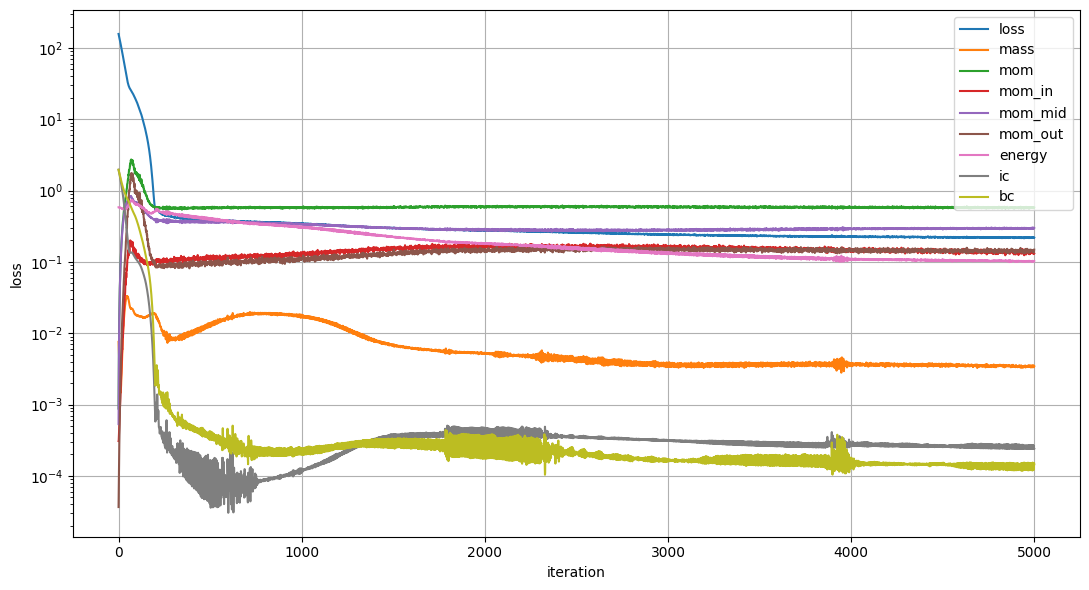

In [17]:
def plot_history(history):
    df = pd.DataFrame(history)

    keys = [
        "loss",
        "mass",
        "mom",
        "mom_in",
        "mom_mid",
        "mom_out",
        "energy",
        "ic",
        "bc",
    ]

    plt.figure(figsize=(11, 6))

    for key in keys:
        if key in df:
            plt.semilogy(df[key].to_numpy(), label=key)

    plt.xlabel("iteration")
    plt.ylabel("loss")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_history(history)

In [18]:
@torch.no_grad()
def validate(model, physics, case, forcing, device, dtype=torch.float32):
    model.eval()

    tau = torch.tensor(forcing.tau.copy(), device=device, dtype=dtype).reshape(-1, 1)
    t = tau * case.w0 / case.L

    z_in = torch.zeros_like(t)
    z_out = torch.ones_like(t)

    G_in, _, pi_in, _, _, _ = physics.fields(z_in, t)
    G_out, _, pi_out, _, _, _ = physics.fields(z_out, t)

    flow_in_pinn = case.A * case.rho_pc * case.w0 * G_in
    flow_out_pinn = case.A * case.rho_pc * case.w0 * G_out

    Q = torch.tensor(forcing.power.copy(), device=device, dtype=dtype).reshape(-1, 1)

    ntpc_pinn = (
        case.beta_pc
        / case.Cp_pc
        * Q
        / flow_in_pinn
    )

    model.train()

    return {
        "time": forcing.time,
        "flow_in_base": forcing.flow_in,
        "flow_out_base": forcing.flow_out,
        "ntpc_base": forcing.ntpc,
        "flow_in_pinn": flow_in_pinn.cpu().numpy().reshape(-1),
        "flow_out_pinn": flow_out_pinn.cpu().numpy().reshape(-1),
        "ntpc_pinn": ntpc_pinn.cpu().numpy().reshape(-1),
        "pi_in_pinn": pi_in.cpu().numpy().reshape(-1),
        "pi_out_pinn": pi_out.cpu().numpy().reshape(-1),
        "pi_in_target": np.full_like(forcing.time, case.dpi_star, dtype=float),
        "pi_out_target": np.zeros_like(forcing.time, dtype=float),
    }


val = validate(model, physics, case, forcing, device, dtype)

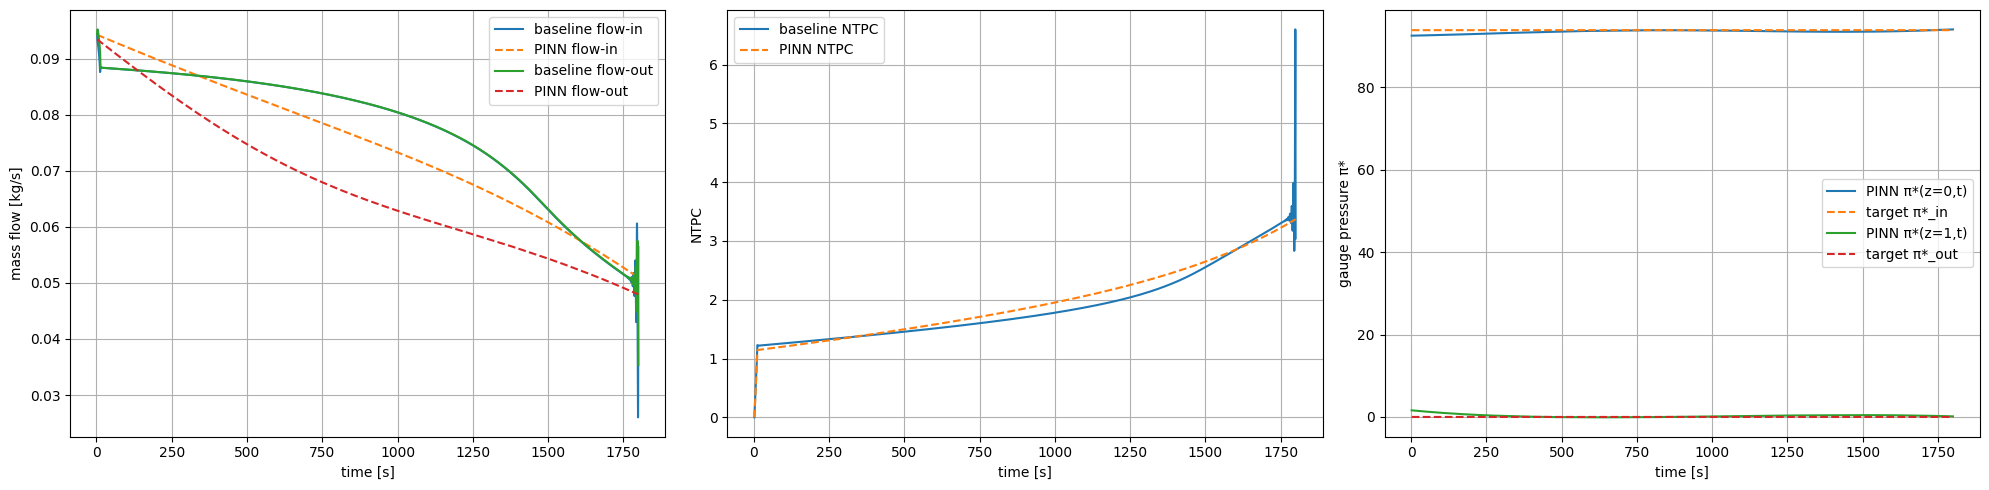

In [19]:
def plot_validation(val):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    ax = axes[0]
    ax.plot(val["time"], val["flow_in_base"], label="baseline flow-in")
    ax.plot(val["time"], val["flow_in_pinn"], "--", label="PINN flow-in")

    ax.plot(val["time"], val["flow_out_base"], label="baseline flow-out")
    ax.plot(val["time"], val["flow_out_pinn"], "--", label="PINN flow-out")

    ax.set_xlabel("time [s]")
    ax.set_ylabel("mass flow [kg/s]")
    ax.grid(True)
    ax.legend()

    ax = axes[1]
    ax.plot(val["time"], val["ntpc_base"], label="baseline NTPC")
    ax.plot(val["time"], val["ntpc_pinn"], "--", label="PINN NTPC")

    ax.set_xlabel("time [s]")
    ax.set_ylabel("NTPC")
    ax.grid(True)
    ax.legend()

    ax = axes[2]
    ax.plot(val["time"], val["pi_in_pinn"], label="PINN π*(z=0,t)")
    ax.plot(val["time"], val["pi_in_target"], "--", label="target π*_in")

    ax.plot(val["time"], val["pi_out_pinn"], label="PINN π*(z=1,t)")
    ax.plot(val["time"], val["pi_out_target"], "--", label="target π*_out")

    ax.set_xlabel("time [s]")
    ax.set_ylabel("gauge pressure π*")
    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()

plot_validation(val)

In [20]:
def rmse(a, b):
    a = np.asarray(a)
    b = np.asarray(b)

    return float(np.sqrt(np.mean((a - b) ** 2)))


print("RMSE flow-in :", rmse(val["flow_in_base"], val["flow_in_pinn"]))
print("RMSE flow-out:", rmse(val["flow_out_base"], val["flow_out_pinn"]))
print("RMSE NTPC    :", rmse(val["ntpc_base"], val["ntpc_pinn"]))

RMSE flow-in : 0.0046891315421023205
RMSE flow-out: 0.012317584490393258
RMSE NTPC    : 0.1498264144711518


In [21]:
@torch.no_grad()
def boundary_field_stats(model, physics, case, forcing, device, dtype=torch.float32):
    model.eval()

    tau = torch.as_tensor(forcing.tau, device=device, dtype=dtype).reshape(-1, 1)
    t = tau * case.w0 / case.L

    z0 = torch.zeros_like(t)
    z1 = torch.ones_like(t)

    G0, h0, pi0, Ghat0, hhat0, Pihat0 = physics.fields(z0, t)
    G1, h1, pi1, Ghat1, hhat1, Pihat1 = physics.fields(z1, t)

    def stat(name, x):
        x = x.detach().cpu().numpy().reshape(-1)
        print(
            f"{name:14s}: "
            f"min={x.min(): .4e}, "
            f"mean={x.mean(): .4e}, "
            f"max={x.max(): .4e}, "
            f"std={x.std(): .4e}"
        )

    print("=== TARGETS ===")
    print(f"G0*        = {case.G0_star:.6e}")
    print(f"h_in*      = {case.h0_star:.6e}")
    print(f"pi_in*     = {case.dpi_star:.6e}")
    print(f"pi_out*    = 0")
    print()

    print("=== PHYSICAL SCALED FIELDS ===")
    stat("G(z=0)", G0)
    stat("G(z=1)", G1)
    stat("h(z=0)", h0)
    stat("h(z=1)", h1)
    stat("pi(z=0)", pi0)
    stat("pi(z=1)", pi1)

    print()
    print("=== RAW NETWORK OUTPUTS ===")
    stat("G_hat(z=0)", Ghat0)
    stat("G_hat(z=1)", Ghat1)
    stat("h_hat(z=0)", hhat0)
    stat("h_hat(z=1)", hhat1)
    stat("Pi_hat(z=0)", Pihat0)
    stat("Pi_hat(z=1)", Pihat1)

    model.train()


boundary_field_stats(model, physics, case, forcing, device, dtype)

=== TARGETS ===
G0*        = 2.698876e+00
h_in*      = -2.000000e+00
pi_in*     = 9.385098e+01
pi_out*    = 0

=== PHYSICAL SCALED FIELDS ===
G(z=0)        : min= 1.4584e+00, mean= 2.1069e+00, max= 2.6964e+00, std= 3.2837e-01
G(z=1)        : min= 1.3717e+00, mean= 1.8843e+00, max= 2.6735e+00, std= 3.2540e-01
h(z=0)        : min=-2.0404e+00, mean=-2.0021e+00, max=-1.9558e+00, std= 1.5387e-02
h(z=1)        : min=-1.9428e+00, mean=-9.3656e-01, max= 1.5312e-01, std= 6.2692e-01
pi(z=0)       : min= 9.2512e+01, mean= 9.3528e+01, max= 9.4034e+01, std= 3.0787e-01
pi(z=1)       : min=-8.9958e-02, mean= 2.3598e-01, max= 1.6071e+00, std= 2.6073e-01

=== RAW NETWORK OUTPUTS ===
G_hat(z=0)    : min= 5.4037e-01, mean= 7.8065e-01, max= 9.9910e-01, std= 1.2167e-01
G_hat(z=1)    : min= 5.0826e-01, mean= 6.9816e-01, max= 9.9061e-01, std= 1.2057e-01
h_hat(z=0)    : min=-1.0202e+00, mean=-1.0010e+00, max=-9.7788e-01, std= 7.6934e-03
h_hat(z=1)    : min=-9.7142e-01, mean=-4.6828e-01, max= 7.6561e-02, std= 

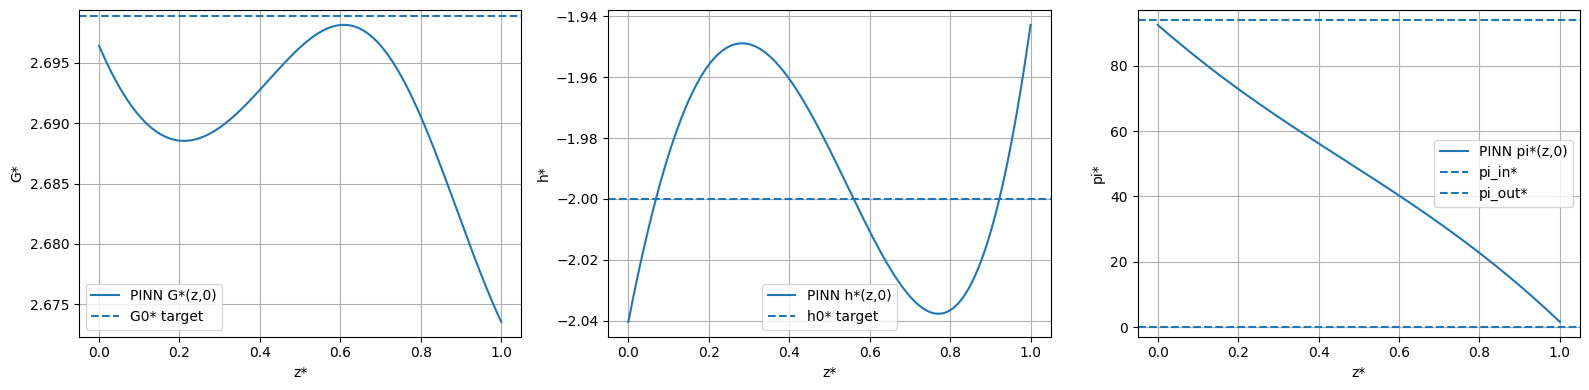

In [22]:
@torch.no_grad()
def plot_ic_profiles(model, physics, case, device, dtype=torch.float32):
    model.eval()

    z = torch.linspace(0, 1, 400, device=device, dtype=dtype).reshape(-1, 1)
    t = torch.zeros_like(z)

    G, h, pi, _, _, _ = physics.fields(z, t)

    z_np = z.cpu().numpy().reshape(-1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(z_np, G.cpu().numpy().reshape(-1), label="PINN G*(z,0)")
    axes[0].axhline(case.G0_star, linestyle="--", label="G0* target")
    axes[0].set_xlabel("z*")
    axes[0].set_ylabel("G*")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(z_np, h.cpu().numpy().reshape(-1), label="PINN h*(z,0)")
    axes[1].axhline(case.h0_star, linestyle="--", label="h0* target")
    axes[1].set_xlabel("z*")
    axes[1].set_ylabel("h*")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(z_np, pi.cpu().numpy().reshape(-1), label="PINN pi*(z,0)")
    axes[2].axhline(case.dpi_star, linestyle="--", label="pi_in*")
    axes[2].axhline(0.0, linestyle="--", label="pi_out*")
    axes[2].set_xlabel("z*")
    axes[2].set_ylabel("pi*")
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    model.train()


plot_ic_profiles(model, physics, case, device, dtype)

In [23]:
def normalized_error_report(history):
    last = history[-1]

    print("=== NORMALIZED ERROR REPORT ===")

    for key in [
        "ic_G",
        "ic_h",
        "bc_h_in",
        "bc_pi_in",
        "bc_pi_out",
        "mass",
        "mom",
        "energy",
    ]:
        if key in last:
            print(f"{key:12s}: RMS = {math.sqrt(last[key]):.6e}, MSE = {last[key]:.6e}")


normalized_error_report(history)

=== NORMALIZED ERROR REPORT ===
ic_G        : RMS = 3.026757e-03, MSE = 9.161256e-06
ic_h        : RMS = 1.519599e-02, MSE = 2.309180e-04
bc_h_in     : RMS = 8.947777e-03, MSE = 8.006272e-05
bc_pi_in    : RMS = 4.997701e-03, MSE = 2.497701e-05
bc_pi_out   : RMS = 6.362824e-03, MSE = 4.048553e-05
mass        : RMS = 5.890824e-02, MSE = 3.470181e-03
mom         : RMS = 7.607806e-01, MSE = 5.787871e-01
energy      : RMS = 3.206567e-01, MSE = 1.028207e-01


In [24]:
@torch.no_grad()
def eval_fields_on_grid(model, physics, case, device, dtype=torch.float32, n_z=201, n_t=300):
    model.eval()

    z = torch.linspace(0.0, 1.0, n_z, device=device, dtype=dtype)
    t = torch.linspace(0.0, case.t_end_star, n_t, device=device, dtype=dtype)

    Z, T = torch.meshgrid(z, t, indexing="ij")

    zz = Z.reshape(-1, 1)
    tt = T.reshape(-1, 1)

    G, h, pi, _, _, _ = physics.fields(zz, tt)
    rho, chi_h = physics.eos25(h)

    out = {
        "z": z.cpu().numpy(),
        "t_star": t.cpu().numpy(),
        "time_s": (t.cpu().numpy() * case.L / case.w0) + 2.0,
        "G": G.cpu().numpy().reshape(n_z, n_t),
        "h": h.cpu().numpy().reshape(n_z, n_t),
        "pi": pi.cpu().numpy().reshape(n_z, n_t),
        "rho": rho.cpu().numpy().reshape(n_z, n_t),
        "chi_h": chi_h.cpu().numpy().reshape(n_z, n_t),
    }

    model.train()
    return out


grid = eval_fields_on_grid(
    model=model,
    physics=physics,
    case=case,
    device=device,
    dtype=dtype,
    n_z=201,
    n_t=300,
)

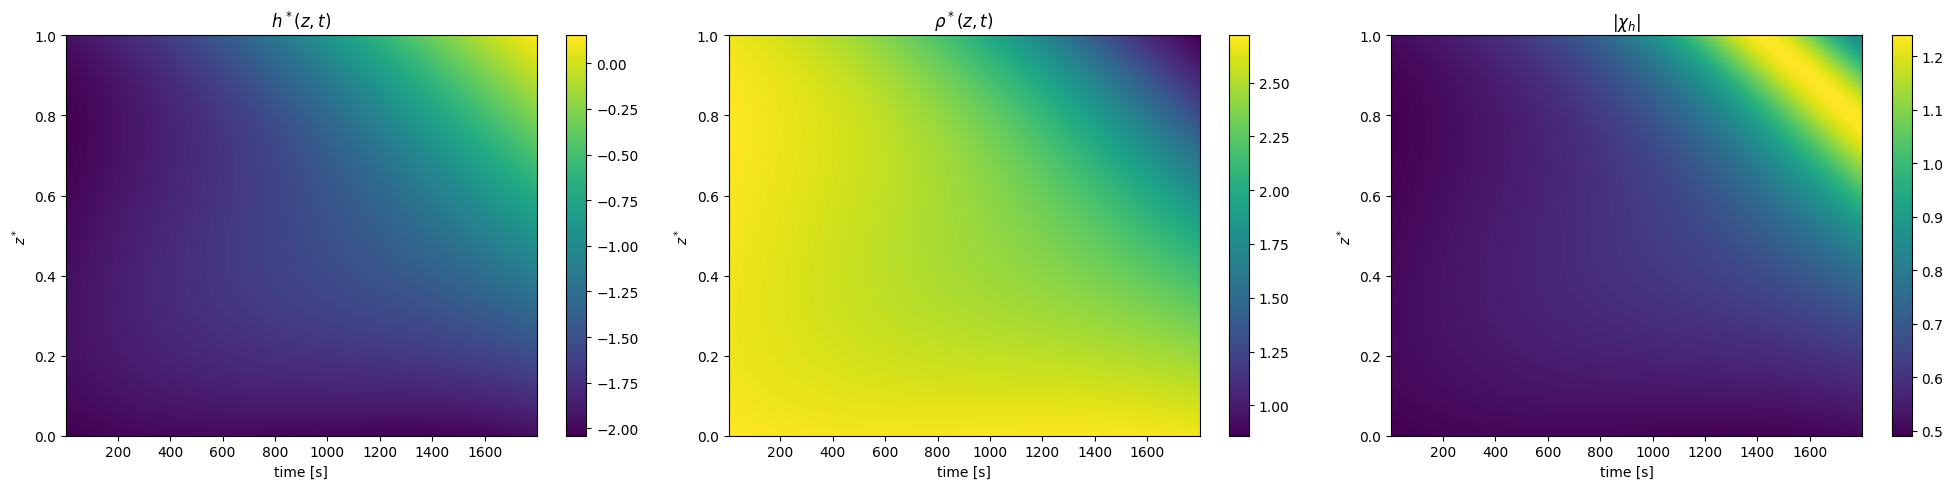

In [25]:
def plot_heatmaps(grid):
    z = grid["z"]
    time = grid["time_s"]

    fields = [
        ("h", r"$h^*(z,t)$"),
        ("rho", r"$\rho^*(z,t)$"),
        ("chi_h", r"$\chi_h=d\rho^*/dh^*$"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    for ax, (key, title) in zip(axes, fields):
        data = grid[key]

        if key == "chi_h":
            data = np.abs(data)
            title = r"$|\chi_h|$"

        im = ax.imshow(
            data,
            origin="lower",
            aspect="auto",
            extent=[time.min(), time.max(), z.min(), z.max()],
        )

        ax.set_title(title)
        ax.set_xlabel("time [s]")
        ax.set_ylabel(r"$z^*$")
        fig.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()


plot_heatmaps(grid)

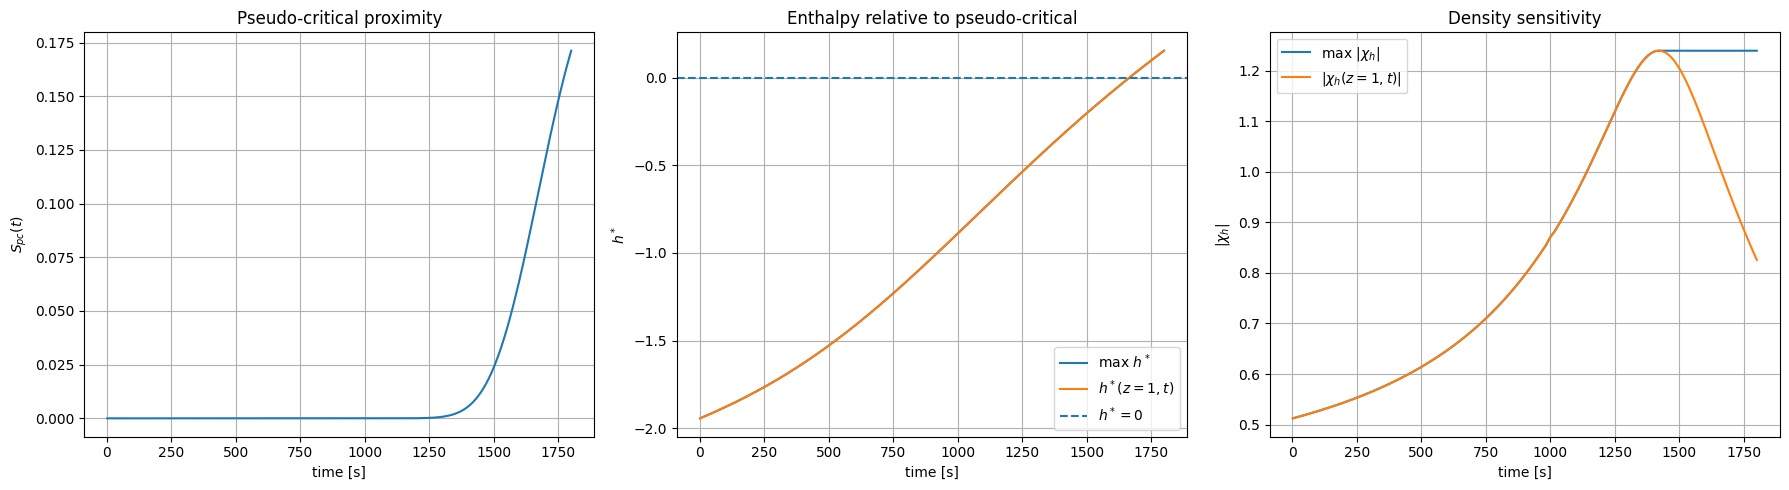

In [26]:
def pseudo_critical_indicator(grid, sigma_h=0.25):
    z = grid["z"]
    h = grid["h"]
    chi_h = grid["chi_h"]

    kernel = np.exp(-(h / sigma_h) ** 2)

    S_pc = np.trapezoid(kernel, z, axis=0)
    h_max = h.max(axis=0)
    h_out = h[-1, :]
    chi_max = np.max(np.abs(chi_h), axis=0)
    chi_out = np.abs(chi_h[-1, :])

    return {
        "time": grid["time_s"],
        "S_pc": S_pc,
        "h_max": h_max,
        "h_out": h_out,
        "chi_max": chi_max,
        "chi_out": chi_out,
    }


pc = pseudo_critical_indicator(grid, sigma_h=0.25)


def plot_pseudo_critical_indicator(pc):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax = axes[0]
    ax.plot(pc["time"], pc["S_pc"])
    ax.set_xlabel("time [s]")
    ax.set_ylabel(r"$S_{pc}(t)$")
    ax.set_title("Pseudo-critical proximity")
    ax.grid(True)

    ax = axes[1]
    ax.plot(pc["time"], pc["h_max"], label=r"max $h^*$")
    ax.plot(pc["time"], pc["h_out"], label=r"$h^*(z=1,t)$")
    ax.axhline(0.0, linestyle="--", label=r"$h^*=0$")
    ax.set_xlabel("time [s]")
    ax.set_ylabel(r"$h^*$")
    ax.set_title("Enthalpy relative to pseudo-critical")
    ax.grid(True)
    ax.legend()

    ax = axes[2]
    ax.plot(pc["time"], pc["chi_max"], label=r"max $|\chi_h|$")
    ax.plot(pc["time"], pc["chi_out"], label=r"$|\chi_h(z=1,t)|$")
    ax.set_xlabel("time [s]")
    ax.set_ylabel(r"$|\chi_h|$")
    ax.set_title("Density sensitivity")
    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_pseudo_critical_indicator(pc)

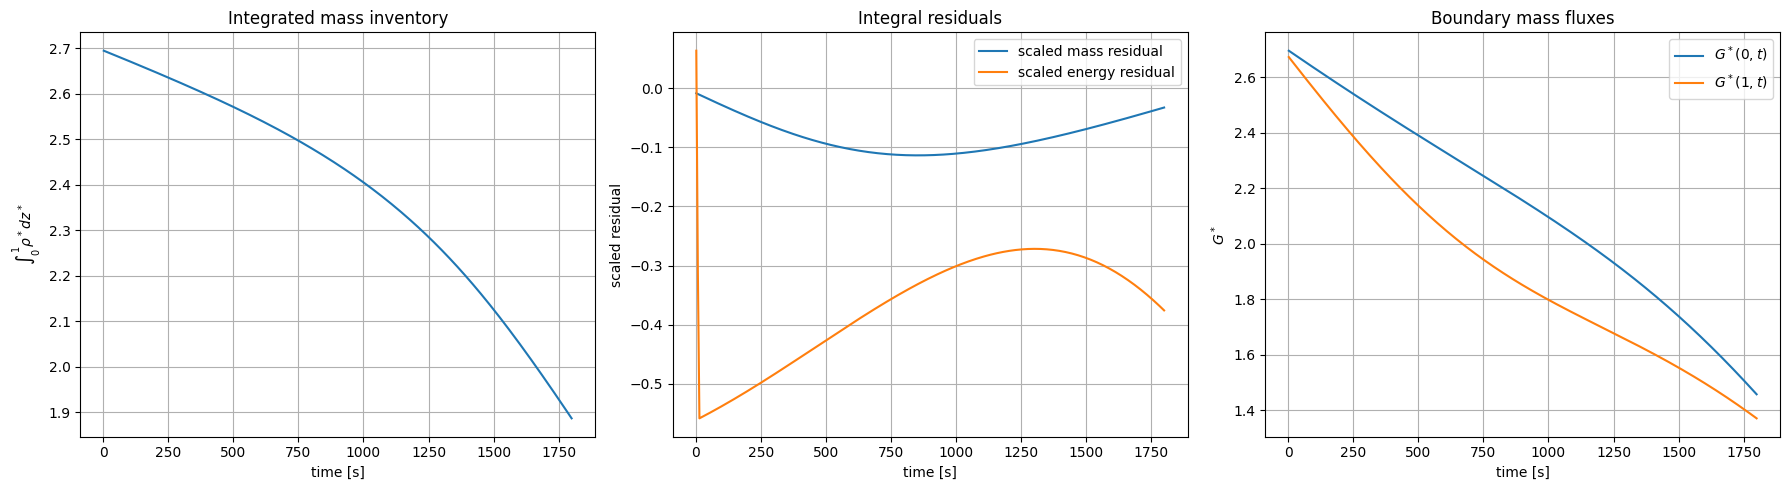

Integral mass residual RMS: 0.08487281
Integral energy residual RMS: 0.37822852


In [27]:
@torch.no_grad()
def integral_residuals(grid, physics, case, forcing, device, dtype=torch.float32):
    z = grid["z"]
    t_star = grid["t_star"]
    time = grid["time_s"]

    G = grid["G"]
    h = grid["h"]
    rho = grid["rho"]

    mass_int = np.trapezoid(rho, z, axis=0)
    energy_int = np.trapezoid(rho * h, z, axis=0)

    dmass_dt = np.gradient(mass_int, t_star)
    denergy_dt = np.gradient(energy_int, t_star)

    G_in = G[0, :]
    G_out = G[-1, :]

    Gh_in = G[0, :] * h[0, :]
    Gh_out = G[-1, :] * h[-1, :]

    t_tensor = torch.tensor(t_star.copy(), device=device, dtype=dtype).reshape(-1, 1)
    NQ = physics.NQ_prime(t_tensor).detach().cpu().numpy().reshape(-1)

    R_mass_int = dmass_dt + G_out - G_in
    R_energy_int = denergy_dt + Gh_out - Gh_in - NQ

    return pd.DataFrame({
        "time": time,
        "mass_int": mass_int,
        "energy_int": energy_int,
        "R_mass_int": R_mass_int,
        "R_energy_int": R_energy_int,
        "R_mass_int_scaled": R_mass_int / case.mass_scale,
        "R_energy_int_scaled": R_energy_int / case.energy_scale,
        "G_in": G_in,
        "G_out": G_out,
        "NQ": NQ,
    })


int_res = integral_residuals(grid, physics, case, forcing, device, dtype)


def plot_integral_residuals(int_res):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax = axes[0]
    ax.plot(int_res["time"], int_res["mass_int"])
    ax.set_xlabel("time [s]")
    ax.set_ylabel(r"$\int_0^1 \rho^* dz^*$")
    ax.set_title("Integrated mass inventory")
    ax.grid(True)

    ax = axes[1]
    ax.plot(int_res["time"], int_res["R_mass_int_scaled"], label="scaled mass residual")
    ax.plot(int_res["time"], int_res["R_energy_int_scaled"], label="scaled energy residual")
    ax.set_xlabel("time [s]")
    ax.set_ylabel("scaled residual")
    ax.set_title("Integral residuals")
    ax.grid(True)
    ax.legend()

    ax = axes[2]
    ax.plot(int_res["time"], int_res["G_in"], label=r"$G^*(0,t)$")
    ax.plot(int_res["time"], int_res["G_out"], label=r"$G^*(1,t)$")
    ax.set_xlabel("time [s]")
    ax.set_ylabel(r"$G^*$")
    ax.set_title("Boundary mass fluxes")
    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_integral_residuals(int_res)

print("Integral mass residual RMS:", np.sqrt(np.mean(int_res["R_mass_int_scaled"] ** 2)))
print("Integral energy residual RMS:", np.sqrt(np.mean(int_res["R_energy_int_scaled"] ** 2)))

In [32]:
def pressure_budget(model, physics, case, device, dtype=torch.float32, n_z=401, n_t=200):
    model.train()

    z_base = torch.linspace(0.0, 1.0, n_z, device=device, dtype=dtype).reshape(-1, 1)
    t_vals = torch.linspace(0.0, case.t_end_star, n_t, device=device, dtype=dtype)

    rows = []

    for t0 in t_vals:
        z = z_base.clone().detach().requires_grad_(True)
        t = torch.full_like(z, t0.item()).requires_grad_(True)

        G, h, pi, _, _, _ = physics.fields(z, t)
        rho, _ = physics.eos25(h)

        G_t = d(G, t)

        flux = G**2 / rho

        delta0 = delta_inlet(z, physics.alpha)
        delta1 = delta_outlet(z, physics.alpha)

        accel = torch.trapezoid(G_t.reshape(-1), z.reshape(-1))
        flux_jump = flux[-1, 0] - flux[0, 0]
        gravity = torch.trapezoid((rho / case.Fr).reshape(-1), z.reshape(-1))

        Lambda_dyn, signed_loss_flux, Re, lambda_darcy = physics.distributed_friction(
            G=G,
            h=h,
            rho=rho,
        )

        friction_dist = torch.trapezoid(
            (Lambda_dyn * signed_loss_flux).reshape(-1),
            z.reshape(-1),
        )

        local_in = torch.trapezoid(
            (0.5 * case.kin * delta_inlet(z, physics.alpha) * signed_loss_flux).reshape(-1),
            z.reshape(-1),
        )

        local_out = torch.trapezoid(
            (0.5 * case.kout * delta_outlet(z, physics.alpha) * signed_loss_flux).reshape(-1),
            z.reshape(-1),
        )

        pressure_drop = pi[0, 0] - pi[-1, 0]

        rhs = accel + flux_jump + gravity + friction_dist + local_in + local_out
        residual = rhs - pressure_drop

        rows.append({
            "t_star": float(t0.detach().cpu()),
            "time": float(t0.detach().cpu()) * case.L / case.w0 + 2.0,
            "pressure_drop": float(pressure_drop.detach().cpu()),
            "accel": float(accel.detach().cpu()),
            "flux_jump": float(flux_jump.detach().cpu()),
            "gravity": float(gravity.detach().cpu()),
            "friction_dist": float(friction_dist.detach().cpu()),
            "local_in": float(local_in.detach().cpu()),
            "local_out": float(local_out.detach().cpu()),
            "rhs": float(rhs.detach().cpu()),
            "budget_residual": float(residual.detach().cpu()),
        })

    return pd.DataFrame(rows)


budget = pressure_budget(
    model=model,
    physics=physics,
    case=case,
    device=device,
    dtype=dtype,
    n_z=401,
    n_t=200,
)

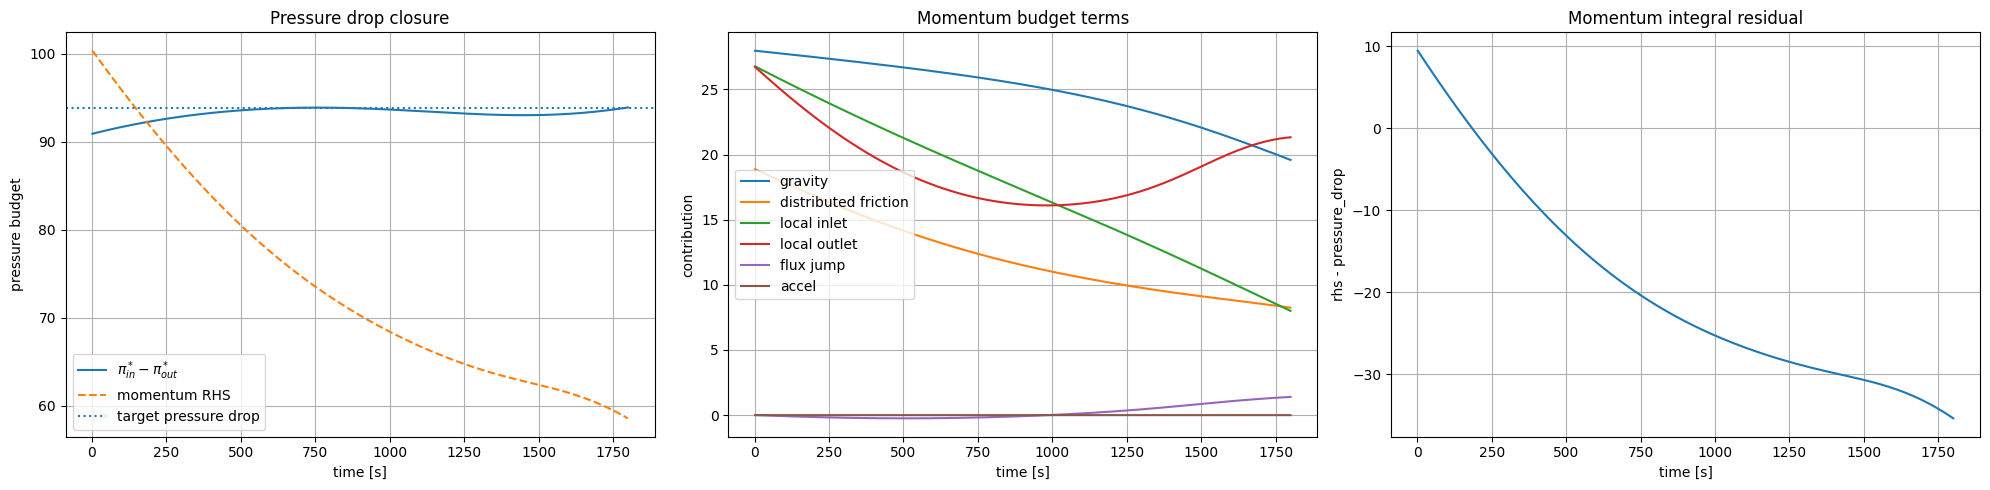

Pressure budget residual RMS: 23.003056715914244
Mean pressure drop: 93.19933292388916
Target pressure drop: 93.85097958770778


In [33]:
def plot_pressure_budget(budget):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    ax = axes[0]
    ax.plot(budget["time"], budget["pressure_drop"], label=r"$\pi_{in}^*-\pi_{out}^*$")
    ax.plot(budget["time"], budget["rhs"], "--", label="momentum RHS")
    ax.axhline(case.dpi_star, linestyle=":", label="target pressure drop")
    ax.set_xlabel("time [s]")
    ax.set_ylabel("pressure budget")
    ax.set_title("Pressure drop closure")
    ax.grid(True)
    ax.legend()

    ax = axes[1]
    ax.plot(budget["time"], budget["gravity"], label="gravity")
    ax.plot(budget["time"], budget["friction_dist"], label="distributed friction")
    ax.plot(budget["time"], budget["local_in"], label="local inlet")
    ax.plot(budget["time"], budget["local_out"], label="local outlet")
    ax.plot(budget["time"], budget["flux_jump"], label="flux jump")
    ax.plot(budget["time"], budget["accel"], label="accel")
    ax.set_xlabel("time [s]")
    ax.set_ylabel("contribution")
    ax.set_title("Momentum budget terms")
    ax.grid(True)
    ax.legend()

    ax = axes[2]
    ax.plot(budget["time"], budget["budget_residual"])
    ax.set_xlabel("time [s]")
    ax.set_ylabel("rhs - pressure_drop")
    ax.set_title("Momentum integral residual")
    ax.grid(True)

    plt.tight_layout()
    plt.show()


plot_pressure_budget(budget)

print("Pressure budget residual RMS:", np.sqrt(np.mean(budget["budget_residual"] ** 2)))
print("Mean pressure drop:", budget["pressure_drop"].mean())
print("Target pressure drop:", case.dpi_star)

In [30]:
def summarize_early_late(grid, int_res, budget, split_time=1100.0):
    time = grid["time_s"]

    early = time < split_time
    late = time >= split_time

    def mean_range(name, arr):
        return {
            f"{name}_early_mean": float(np.mean(arr[early])),
            f"{name}_late_mean": float(np.mean(arr[late])),
            f"{name}_early_min": float(np.min(arr[early])),
            f"{name}_late_min": float(np.min(arr[late])),
            f"{name}_early_max": float(np.max(arr[early])),
            f"{name}_late_max": float(np.max(arr[late])),
        }

    pc = pseudo_critical_indicator(grid)

    rows = {}
    rows.update(mean_range("S_pc", pc["S_pc"]))
    rows.update(mean_range("h_out", pc["h_out"]))
    rows.update(mean_range("chi_max", pc["chi_max"]))

    b_early = budget["time"] < split_time
    b_late = budget["time"] >= split_time

    for col in [
        "pressure_drop",
        "gravity",
        "friction_dist",
        "local_in",
        "local_out",
        "accel",
        "flux_jump",
        "budget_residual",
    ]:
        rows[f"{col}_early_mean"] = float(budget.loc[b_early, col].mean())
        rows[f"{col}_late_mean"] = float(budget.loc[b_late, col].mean())

    i_early = int_res["time"] < split_time
    i_late = int_res["time"] >= split_time

    rows["R_mass_int_early_rms"] = float(np.sqrt(np.mean(int_res.loc[i_early, "R_mass_int_scaled"] ** 2)))
    rows["R_mass_int_late_rms"] = float(np.sqrt(np.mean(int_res.loc[i_late, "R_mass_int_scaled"] ** 2)))

    rows["R_energy_int_early_rms"] = float(np.sqrt(np.mean(int_res.loc[i_early, "R_energy_int_scaled"] ** 2)))
    rows["R_energy_int_late_rms"] = float(np.sqrt(np.mean(int_res.loc[i_late, "R_energy_int_scaled"] ** 2)))

    return pd.DataFrame.from_dict(rows, orient="index", columns=["value"])


summary_late = summarize_early_late(grid, int_res, budget, split_time=1100.0)
summary_late.to_csv("summary_late.csv")

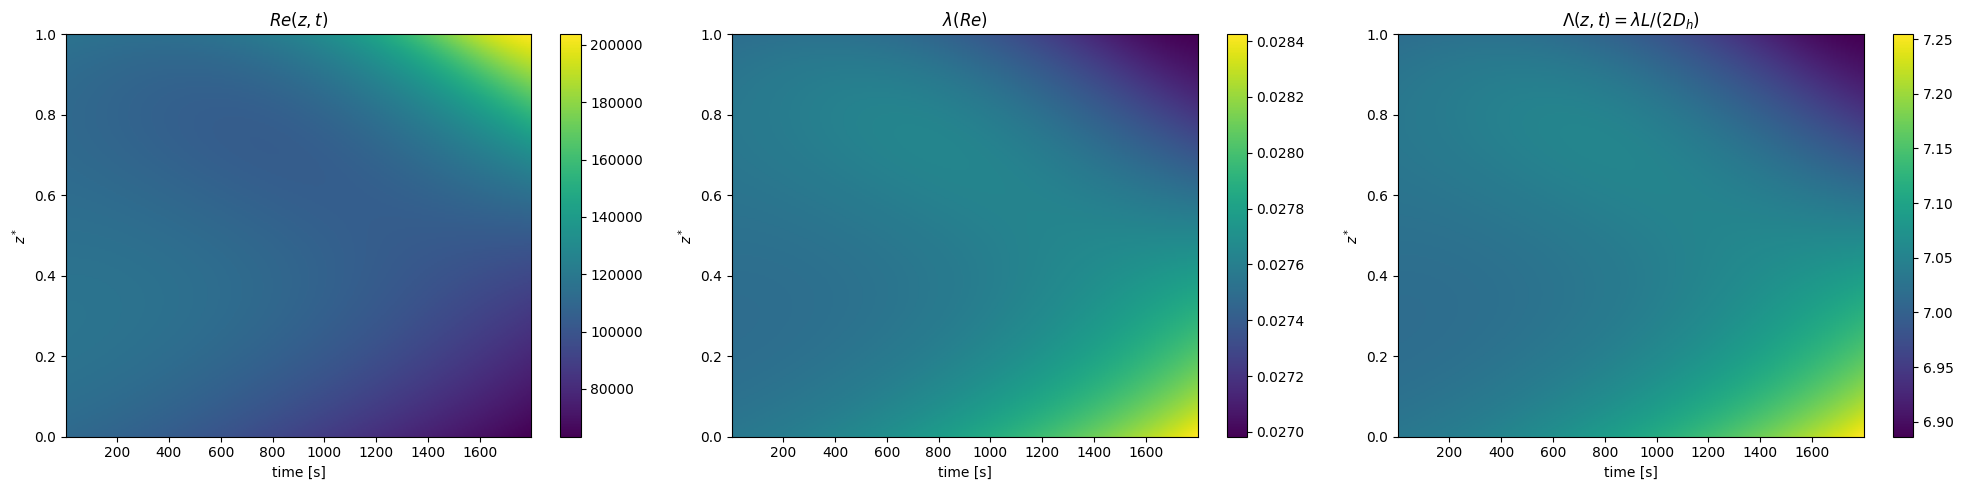

In [31]:
@torch.no_grad()
def friction_diagnostics(model, physics, case, device, dtype=torch.float32, n_z=201, n_t=300):
    model.eval()

    z = torch.linspace(0.0, 1.0, n_z, device=device, dtype=dtype)
    t = torch.linspace(0.0, case.t_end_star, n_t, device=device, dtype=dtype)

    Z, T = torch.meshgrid(z, t, indexing="ij")

    zz = Z.reshape(-1, 1)
    tt = T.reshape(-1, 1)

    G, h, _, _, _, _ = physics.fields(zz, tt)
    rho, _ = physics.eos25(h)

    Lambda_dyn, _, Re, lambda_darcy = physics.distributed_friction(G, h, rho)

    out = {
        "z": z.cpu().numpy(),
        "time": (t.cpu().numpy() * case.L / case.w0) + 2.0,
        "Re": Re.cpu().numpy().reshape(n_z, n_t),
        "lambda": lambda_darcy.cpu().numpy().reshape(n_z, n_t),
        "Lambda": Lambda_dyn.cpu().numpy().reshape(n_z, n_t),
    }

    model.train()
    return out


def plot_friction_diagnostics(fr):
    z = fr["z"]
    time = fr["time"]

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    for ax, key, title in zip(
        axes,
        ["Re", "lambda", "Lambda"],
        [r"$Re(z,t)$", r"$\lambda(Re)$", r"$\Lambda(z,t)=\lambda L/(2D_h)$"],
    ):
        im = ax.imshow(
            fr[key],
            origin="lower",
            aspect="auto",
            extent=[time.min(), time.max(), z.min(), z.max()],
        )

        ax.set_title(title)
        ax.set_xlabel("time [s]")
        ax.set_ylabel(r"$z^*$")
        fig.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()


fr = friction_diagnostics(model, physics, case, device, dtype)
plot_friction_diagnostics(fr)